In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path


def load_roi(path="mihi_roi_postel_px.npz"):
    d = np.load(path)

    return {
        "px": d["px"],
        "py": d["py"],
        "map_shape": tuple(d["map_shape"]),
        "lon_carr": float(d["lon_carr"]),
        "lat_carr": float(d["lat_carr"]),
    }


def check_shape(emap, shape_ref):
    if emap.shape != shape_ref:
        raise ValueError(
            f"Mapa {emap.shape} ≠ mapa de referencia {shape_ref}"
        )


def roi_mask(px, py, shape):
    """
    Máscara booleana.
    True para los píxeles cuyo centro está dentro de la ROI.
    """
    ny, nx = shape

    yy, xx = np.mgrid[0:ny, 0:nx]

    poly = Path(
        np.column_stack([px, py])
    )

    inside = poly.contains_points(
        np.column_stack([
            xx.ravel(),
            yy.ravel()
        ])
    )

    return inside.reshape(shape)


def plot_roi(ax, px, py, **kw):

    kw.setdefault("color", "cyan")
    kw.setdefault("lw", 1.5)

    ax.plot(px, py, **kw)

In [2]:
roi = load_roi("mihi_roi_postel_px.npz")

px_roi = roi["px"]
py_roi = roi["py"]
shape_roi = roi["map_shape"]

print("Mapa de referencia:", shape_roi)
print("Centro aproximado Carrington:")
print("L =", roi["lon_carr"])
print("B =", roi["lat_carr"])

Mapa de referencia: (np.int64(1024), np.int64(1024))
Centro aproximado Carrington:
L = 106.24285436646456
B = 9.4939136059252


In [3]:
import numpy as np

# ============================================================
# LOAD PORE MASKS
# ============================================================

pores_file = "../data/2018_08_25/pores/ranked_regions_MAG_24.npz"

pores = np.load(pores_file)

region_names = pores["region_name"]
original_ids = pores["original_pore_id"]

x_centers = pores["x_center"]
y_centers = pores["y_center"]
radii = pores["r_eq"]

circle_masks = pores["circle_masks"]

print("Number of pores:", len(region_names))
print("Mask shape:", circle_masks.shape)

Number of pores: 12
Mask shape: (12, 1024, 1024)


Egression map shape: (1024, 1024)
Pore masks shape: (12, 1024, 1024)


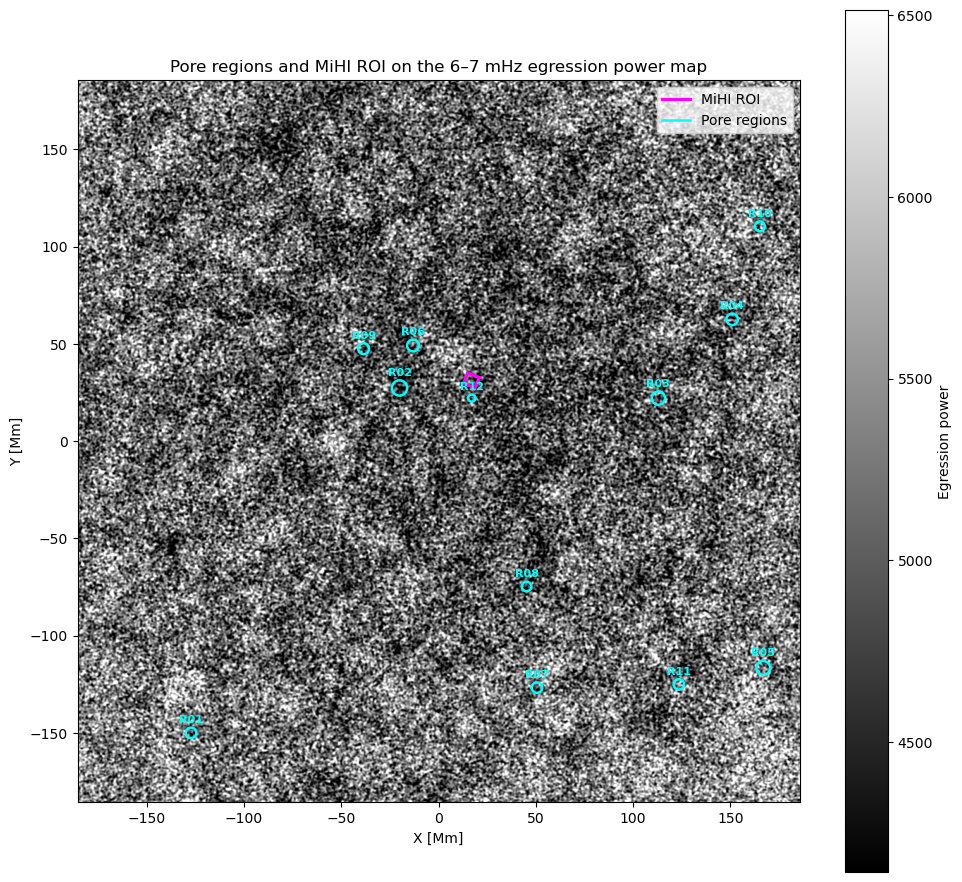

In [4]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# 1. LOAD 6–7 mHz EGRESS POWER MAP
# ============================================================

egress_file = (
    "../data/2018_08_25/"
    "egress_pwr_06.0-07.0mHz_z0000km.fits"
)

with fits.open(egress_file) as hdul:
    egress_map = hdul[0].data.copy()

print("Egression map shape:", egress_map.shape)
print("Pore masks shape:", circle_masks.shape)


# ============================================================
# 2. SPATIAL SCALE
# ============================================================

# 0.5 arcsec/pixel × 725 km/arcsec
spatial_sample = 0.5 * 725 * 0.001  # Mm/pixel

ny, nx = egress_map.shape

# Physical coordinates with (0,0) at the image center
x_min = -nx / 2 * spatial_sample
x_max =  nx / 2 * spatial_sample

y_min = -ny / 2 * spatial_sample
y_max =  ny / 2 * spatial_sample

extent = [x_min, x_max, y_min, y_max]


# ============================================================
# 3. CHECK DIMENSIONS
# ============================================================

if egress_map.shape != circle_masks.shape[1:]:
    raise ValueError(
        f"Egression map shape {egress_map.shape} "
        f"does not match pore mask shape {circle_masks.shape[1:]}"
    )

if tuple(shape_roi) != egress_map.shape:
    raise ValueError(
        f"MiHI ROI reference shape {tuple(shape_roi)} "
        f"does not match egression map shape {egress_map.shape}"
    )


# ============================================================
# 4. CONVERT MiHI ROI PIXELS -> Mm
# ============================================================

px_roi_Mm = (px_roi - nx / 2) * spatial_sample
py_roi_Mm = (py_roi - ny / 2) * spatial_sample


# ============================================================
# 5. PLOT EGRESS POWER MAP
# ============================================================

fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(
    egress_map,
    origin="lower",
    cmap="gray",
    vmin=np.nanpercentile(egress_map, 5),
    vmax=np.nanpercentile(egress_map, 98),
    extent=extent
)


# ============================================================
# 6. OVERLAY MiHI ROI
# ============================================================

ax.plot(
    px_roi_Mm,
    py_roi_Mm,
    color="magenta",
    linewidth=2.2,
    label="MiHI ROI"
)


# ============================================================
# 7. OVERLAY PORE REGIONS
# ============================================================

for name, pore_id, x0, y0, r in zip(
    region_names,
    original_ids,
    x_centers,
    y_centers,
    radii
):

    # Pixel -> Mm
    x0_Mm = (x0 - nx / 2) * spatial_sample
    y0_Mm = (y0 - ny / 2) * spatial_sample
    r_Mm  = r * spatial_sample

    # Equivalent-area circle
    circle = Circle(
        (x0_Mm, y0_Mm),
        r_Mm,
        fill=False,
        linewidth=1.8,
        color="cyan"
    )

    ax.add_patch(circle)

    # Region label
    ax.text(
        x0_Mm,
        y0_Mm + r_Mm + 1.5,
        name,
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="cyan"
    )


# ============================================================
# 8. FORMAT
# ============================================================

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label("Egression power")

ax.set_xlabel("X [Mm]")
ax.set_ylabel("Y [Mm]")

ax.set_title(
    "Pore regions and MiHI ROI on the 6–7 mHz egression power map"
)

# Add a cyan entry to the legend for the pore regions
ax.plot(
    [],
    [],
    color="cyan",
    linewidth=1.8,
    label="Pore regions"
)

ax.legend(
    loc="upper right",
    frameon=True
)

plt.tight_layout()
plt.show()

In [5]:
import os
import numpy as np
from astropy.io import fits

base_path = "../data/2018_08_25"

files = {
    "2.0-3.0 mHz": "egress_pwr_02.0-03.0mHz_z0000km.fits",
    "3.0-4.0 mHz": "egress_pwr_03.0-04.0mHz_z0000km.fits",
    "4.0-5.0 mHz": "egress_pwr_04.0-05.0mHz_z0000km.fits",
    "5.0-6.0 mHz": "egress_pwr_05.0-06.0mHz_z0000km.fits",
    "6.0-7.0 mHz": "egress_pwr_06.0-07.0mHz_z0000km.fits",
    "7.0-8.0 mHz": "egress_pwr_07.0-08.0mHz_z0000km.fits",
    "8.0-9.0 mHz": "egress_pwr_08.0-09.0mHz_z0000km.fits",
    "9.0-10.0 mHz": "egress_pwr_09.0-10.0mHz_z0000km.fits",
    "10.0-11.0 mHz": "egress_pwr_10.0-11.0mHz_z0000km.fits",
}
frequencies = list(files.keys())

egression_maps = []

for freq_band, filename in files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data_map = hdul[0].data.copy()

    egression_maps.append(data_map)

print("Number of maps:", len(egression_maps))
print("Shape of first map:", egression_maps[0].shape)

Number of maps: 9
Shape of first map: (1024, 1024)


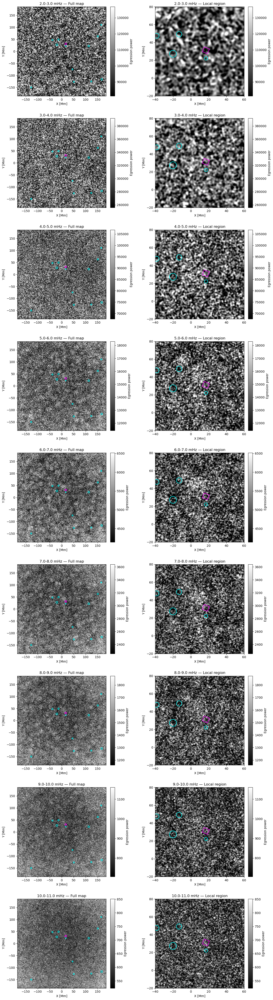

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# ESCALA ESPACIAL
# ============================================================

# HMI: 0.5 arcsec/pixel
# Escala solar aproximada: 725 km/arcsec
spatial_sample = 0.5 * 725 * 0.001  # Mm/pixel


# ============================================================
# GEOMETRÍA DEL MAPA
# ============================================================

ny, nx = egression_maps[0].shape

x_min = -nx / 2 * spatial_sample
x_max =  nx / 2 * spatial_sample
y_min = -ny / 2 * spatial_sample
y_max =  ny / 2 * spatial_sample

extent = [x_min, x_max, y_min, y_max]


# ============================================================
# ROI MiHI: PÍXELES POSTEL → Mm
# ============================================================

x_roi_Mm = (px_roi - nx / 2) * spatial_sample
y_roi_Mm = (py_roi - ny / 2) * spatial_sample


# ============================================================
# POROS: PÍXELES POSTEL → Mm
# ============================================================

x_pores_Mm = (x_centers - nx / 2) * spatial_sample
y_pores_Mm = (y_centers - ny / 2) * spatial_sample
r_pores_Mm = radii * spatial_sample


# ============================================================
# FUNCIÓN PARA DIBUJAR LOS POROS
# ============================================================

def plot_pores(ax):

    for x0, y0, r in zip(
        x_pores_Mm,
        y_pores_Mm,
        r_pores_Mm
    ):

        circle = Circle(
            (x0, y0),
            r,
            fill=False,
            linewidth=1.5,
            color="cyan"
        )

        ax.add_patch(circle)


# ============================================================
# FIGURA
# ============================================================

n_maps = len(egression_maps)

fig, axes = plt.subplots(
    nrows=n_maps,
    ncols=2,
    figsize=(12, 5 * n_maps)
)


# ============================================================
# GRAFICAR CADA BANDA DE FRECUENCIA
# ============================================================

for i, (freq, data_map) in enumerate(
    zip(frequencies, egression_maps)
):

    # --------------------------------------------------------
    # CONTRASTE PARA ESTA BANDA
    # --------------------------------------------------------

    vmin = np.nanpercentile(data_map, 5)
    vmax = np.nanpercentile(data_map, 98)


    # ========================================================
    # COLUMNA 1: MAPA COMPLETO
    # ========================================================

    ax_full = axes[i, 0]

    im_full = ax_full.imshow(
        data_map,
        origin="lower",
        cmap="gray",
        extent=extent,
        vmin=vmin,
        vmax=vmax
    )

    # MiHI ROI
    plot_roi(
        ax_full,
        x_roi_Mm,
        y_roi_Mm,
        color="magenta",
        lw=1.5
    )

    # Pore regions
    plot_pores(ax_full)

    ax_full.set_xlabel("X [Mm]")
    ax_full.set_ylabel("Y [Mm]")
    ax_full.set_title(
        f"{freq} — Full map"
    )

    fig.colorbar(
        im_full,
        ax=ax_full,
        label="Egression power",
        fraction=0.046,
        pad=0.04
    )


    # ========================================================
    # COLUMNA 2: REGIÓN LOCAL
    # ========================================================

    ax_zoom = axes[i, 1]

    im_zoom = ax_zoom.imshow(
        data_map,
        origin="lower",
        cmap="gray",
        extent=extent,
        vmin=vmin,
        vmax=vmax
    )

    # MiHI ROI
    plot_roi(
        ax_zoom,
        x_roi_Mm,
        y_roi_Mm,
        color="magenta",
        lw=1.5
    )

    # Pore regions
    plot_pores(ax_zoom)

    # Zoom espacial
    ax_zoom.set_xlim(-40, 60)
    ax_zoom.set_ylim(-20, 80)

    ax_zoom.set_xlabel("X [Mm]")
    ax_zoom.set_ylabel("Y [Mm]")
    ax_zoom.set_title(
        f"{freq} — Local region"
    )

    fig.colorbar(
        im_zoom,
        ax=ax_zoom,
        label="Egression power",
        fraction=0.046,
        pad=0.04
    )


# ============================================================
# AJUSTAR ESPACIADO
# ============================================================

plt.tight_layout()

fig.subplots_adjust(
    wspace=0.35,
    hspace=0.25
)

plt.show()

In [7]:
import os
import numpy as np
from astropy.io import fits

base_path = "../data/2018_08_25"

cropped_files = {
    "2.0-3.0 mHz":  "egress_pwr_02.0-03.0mHz_z0000km_cropped.fits",
    "3.0-4.0 mHz":  "egress_pwr_03.0-04.0mHz_z0000km_cropped.fits",
    "4.0-5.0 mHz":  "egress_pwr_04.0-05.0mHz_z0000km_cropped.fits",
    "5.0-6.0 mHz":  "egress_pwr_05.0-06.0mHz_z0000km_cropped.fits",
    "6.0-7.0 mHz":  "egress_pwr_06.0-07.0mHz_z0000km_cropped.fits",
    "7.0-8.0 mHz":  "egress_pwr_07.0-08.0mHz_z0000km_cropped.fits",
    "8.0-9.0 mHz":  "egress_pwr_08.0-09.0mHz_z0000km_cropped.fits",
    "9.0-10.0 mHz": "egress_pwr_09.0-10.0mHz_z0000km_cropped.fits",
    "10.0-11.0 mHz":"egress_pwr_10.0-11.0mHz_z0000km_cropped.fits",
}

cropped_frequencies = list(cropped_files.keys())
cropped_maps = []

for freq_band, filename in cropped_files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data_map = hdul[0].data.copy()

    cropped_maps.append(data_map)

    n_total = data_map.size
    n_nan   = np.isnan(data_map).sum()
    n_zero  = np.sum(data_map == 0)
    n_finite = np.isfinite(data_map).sum()

In [8]:
import numpy as np
import pandas as pd

cropped_results = []

for freq, data_map in zip(cropped_frequencies, cropped_maps):

    # Excluir los ceros introducidos por la máscara
    valid_values = data_map[data_map != 0]

    cropped_results.append({
        "Frequency": freq,
        "Cropped map mean": np.mean(valid_values),
        "Cropped map std": np.std(valid_values),
        "Valid pixels": valid_values.size
    })

cropped_results_df = pd.DataFrame(cropped_results)

cropped_results_df

,Frequency,Cropped map mean,Cropped map std,Valid pixels
0,2.0-3.0 mHz,102851.687500,14498.092773,483025
1,3.0-4.0 mHz,312694.031250,36221.382812,483025
2,4.0-5.0 mHz,83052.109375,10341.964844,483025
3,5.0-6.0 mHz,14014.914062,1785.138672,483025
4,6.0-7.0 mHz,5032.001953,615.843872,483025
5,7.0-8.0 mHz,2758.739502,351.906586,483025
6,8.0-9.0 mHz,1415.001953,180.808640,483025
7,9.0-10.0 mHz,862.691406,112.960938,483025
8,10.0-11.0 mHz,636.250549,81.142303,483025


In [9]:
import numpy as np
import pandas as pd

# ============================================================
# 1. MÁSCARA DE LA ROI MiHI
# ============================================================
# (Este era el error: la variable `mask` nunca se había creado.)

ny, nx = egression_maps[0].shape

check_shape(egression_maps[0], tuple(shape_roi))
mihi_mask = roi_mask(px_roi, py_roi, (ny, nx))


# ============================================================
# 2. MÁSCARA CONJUNTA DE LOS SUPERGRÁNULOS
# ============================================================

sg = np.load("../data/2018_08_25/supergranule_masks_geometry.npz")

centers_x = sg["x"]
centers_y = sg["y"]
radii_sg  = sg["radius"]

yy, xx = np.mgrid[0:ny, 0:nx]
supergranule_mask = np.zeros((ny, nx), dtype=bool)

for x0, y0, r in zip(centers_x, centers_y, radii_sg):
    supergranule_mask |= (xx - x0)**2 + (yy - y0)**2 <= r**2


# ============================================================
# 3. MÁSCARAS DE LOS POROS (R01–R12, en orden de score)
# ============================================================

if circle_masks.shape[1:] != (ny, nx):
    raise ValueError(f"Pore masks shape {circle_masks.shape[1:]} != map shape {(ny, nx)}")

# Todas las regiones en un solo diccionario: nombre -> máscara (o None = mapa completo)
regions_to_measure = {
    "Full map":      None,
    "MiHI ROI":      mihi_mask,
    "Supergranules": supergranule_mask,
}
for name, pore_mask in zip(region_names, circle_masks):
    regions_to_measure[str(name)] = pore_mask

print(f"Supergránulos: {len(centers_x)}  |  píxeles: {supergranule_mask.sum()}")
print(f"MiHI ROI: {mihi_mask.sum()} píxeles")
for name, pid, m in zip(region_names, original_ids, circle_masks):
    print(f"  {name} ({pid}): {m.sum()} píxeles")


# ============================================================
# 4. ESTADÍSTICAS POR BANDA Y POR REGIÓN
# ============================================================
# Se excluyen NaN/inf y los ceros (píxeles enmascarados):
# una potencia de egresión exactamente 0 no es física.

exclude_zeros = True

rows = []

for freq, data_map in zip(frequencies, egression_maps):

    check_shape(data_map, (ny, nx))

    valid = np.isfinite(data_map)
    if exclude_zeros:
        valid &= data_map != 0

    for region, m in regions_to_measure.items():

        sel  = valid if m is None else (valid & m)
        vals = data_map[sel]

        rows.append({
            "Frequency":    freq,
            "Region":       region,
            "Mean":         np.mean(vals) if vals.size else np.nan,
            "Std":          np.std(vals)  if vals.size else np.nan,
            "Valid pixels": int(vals.size),
        })

stats_long = pd.DataFrame(rows)

# Orden fijo de columnas y filas
region_order = list(regions_to_measure.keys())
stats_long["Region"]    = pd.Categorical(stats_long["Region"],    categories=region_order, ordered=True)
stats_long["Frequency"] = pd.Categorical(stats_long["Frequency"], categories=frequencies,  ordered=True)


# ============================================================
# 5. TABLAS FINALES
# ============================================================

# (a) Medias: filas = banda, columnas = región
mean_table = stats_long.pivot(index="Frequency", columns="Region", values="Mean")

# (b) Desviaciones estándar
std_table = stats_long.pivot(index="Frequency", columns="Region", values="Std")

# (c) Media normalizada al mapa completo (permite comparar entre bandas)
norm_table = mean_table.div(mean_table["Full map"], axis=0)

# (d) Tabla ancha "estilo anterior": <Región> mean | <Región> std
wide_table = pd.concat(
    {"mean": mean_table, "std": std_table}, axis=1
).swaplevel(axis=1)[[(r, s) for r in region_order for s in ("mean", "std")]]
wide_table.columns = [f"{r} {s}" for r, s in wide_table.columns]

# Guardar
out_dir = "../data/2018_08_25/pores"
stats_long.to_csv(f"{out_dir}/egression_stats_long.csv", index=False)
wide_table.to_csv(f"{out_dir}/egression_stats_wide.csv")

print("\nMedias por banda y región:")
display(mean_table.style.format("{:.4g}"))

print("Desviaciones estándar:")
display(std_table.style.format("{:.4g}"))

print("Media normalizada al mapa completo:")
display(norm_table.style.format("{:.3f}").background_gradient(cmap="RdBu_r", axis=None, vmin=0.5, vmax=1.5))

Supergránulos: 70  |  píxeles: 149716
MiHI ROI: 278 píxeles
  R01 (P29): 178 píxeles
  R02 (P133): 370 píxeles
  R03 (P129): 284 píxeles
  R04 (P159): 209 píxeles
  R05 (P55): 302 píxeles
  R06 (P150): 216 píxeles
  R07 (P43): 175 píxeles
  R08 (P80): 143 píxeles
  R09 (P147): 185 píxeles
  R10 (P194): 154 píxeles
  R11 (P45): 175 píxeles
  R12 (P132): 80 píxeles

Medias por banda y región:


Region,Full map,MiHI ROI,Supergranules,R01,R02,R03,R04,R05,R06,R07,R08,R09,R10,R11,R12
Frequency,,,,,,,,,,,,,,,
2.0-3.0 mHz,1.04e+05,9.169e+04,1.019e+05,1.115e+05,9.817e+04,1.041e+05,1.057e+05,9.914e+04,9.461e+04,1.037e+05,9.64e+04,9.814e+04,1.193e+05,9.956e+04,9.99e+04
3.0-4.0 mHz,3.13e+05,3.073e+05,3.114e+05,2.899e+05,2.949e+05,2.673e+05,2.834e+05,2.957e+05,3.185e+05,3.146e+05,3.305e+05,3.268e+05,2.99e+05,2.773e+05,3.068e+05
4.0-5.0 mHz,8.361e+04,8.411e+04,8.415e+04,7.984e+04,7.648e+04,7.781e+04,7.986e+04,8.519e+04,7.943e+04,8.009e+04,8.307e+04,8.189e+04,8.527e+04,7.909e+04,6.838e+04
5.0-6.0 mHz,1.425e+04,1.393e+04,1.459e+04,1.429e+04,1.296e+04,1.434e+04,1.318e+04,1.484e+04,1.28e+04,1.452e+04,1.313e+04,1.357e+04,1.439e+04,1.446e+04,1.352e+04
6.0-7.0 mHz,5123,4923,5233,4717,4528,5058,4795,5222,4881,4989,4572,4827,5251,5195,4856
7.0-8.0 mHz,2820,2717,2863,2811,2495,2802,2494,2962,2518,2892,2606,2761,3183,2996,2560
8.0-9.0 mHz,1449,1398,1467,1425,1313,1374,1301,1458,1266,1452,1339,1330,1398,1537,1448
9.0-10.0 mHz,887.7,873.6,887.2,890.3,797.8,818.1,881.8,967,791,918.2,814.8,859.2,953.8,876.6,798.7
10.0-11.0 mHz,656.1,639.1,649.9,689.4,600.5,618.9,643.9,665.9,607.9,666.4,608,605.2,660.5,656.1,624.1


Desviaciones estándar:


Region,Full map,MiHI ROI,Supergranules,R01,R02,R03,R04,R05,R06,R07,R08,R09,R10,R11,R12
Frequency,,,,,,,,,,,,,,,
2.0-3.0 mHz,1.47e+04,9542,1.434e+04,9574,9121,1.107e+04,6750,1.337e+04,1.876e+04,1.904e+04,1.129e+04,7140,1.596e+04,1.246e+04,6683
3.0-4.0 mHz,3.613e+04,2.886e+04,3.64e+04,2.275e+04,4.315e+04,2.81e+04,2.776e+04,3.624e+04,2.547e+04,2.973e+04,3.9e+04,2.144e+04,2.719e+04,3.998e+04,2.953e+04
4.0-5.0 mHz,1.044e+04,9388,1.049e+04,8130,7479,8960,7979,8533,1.106e+04,8178,8674,1.065e+04,8209,6725,6377
5.0-6.0 mHz,1826,1436,1822,1668,1397,1586,1493,1391,1642,1442,1579,1235,1279,1677,1179
6.0-7.0 mHz,630.2,568.3,621.6,510.6,524.4,643.7,650.2,545,631,668,457.1,537.4,637.7,640.8,400
7.0-8.0 mHz,365.4,314.1,359.9,314.3,311.4,315.1,321.2,343.6,300.4,284,256.7,308.6,338.3,383.5,264.8
8.0-9.0 mHz,188.8,185.8,183.8,159.5,189.1,178.9,192,159.2,170.9,183.2,153.7,162.9,185.6,198.1,178.4
9.0-10.0 mHz,119.7,92.86,114.4,112.9,97.64,84,103.1,118.5,98.41,95.57,110.8,99.87,132.7,119.1,103.1
10.0-11.0 mHz,86.45,80.51,82.05,81.74,68.62,77.39,79.53,77.3,70.86,85.29,68.07,74.89,81.27,76.63,80.32


Media normalizada al mapa completo:


Region,Full map,MiHI ROI,Supergranules,R01,R02,R03,R04,R05,R06,R07,R08,R09,R10,R11,R12
Frequency,,,,,,,,,,,,,,,
2.0-3.0 mHz,1.000,0.882,0.979,1.072,0.944,1.000,1.016,0.953,0.910,0.997,0.927,0.943,1.147,0.957,0.960
3.0-4.0 mHz,1.000,0.982,0.995,0.926,0.942,0.854,0.905,0.945,1.018,1.005,1.056,1.044,0.955,0.886,0.980
4.0-5.0 mHz,1.000,1.006,1.006,0.955,0.915,0.931,0.955,1.019,0.950,0.958,0.994,0.979,1.020,0.946,0.818
5.0-6.0 mHz,1.000,0.977,1.024,1.003,0.909,1.006,0.924,1.041,0.898,1.019,0.921,0.952,1.009,1.014,0.948
6.0-7.0 mHz,1.000,0.961,1.021,0.921,0.884,0.987,0.936,1.019,0.953,0.974,0.892,0.942,1.025,1.014,0.948
7.0-8.0 mHz,1.000,0.964,1.015,0.997,0.885,0.994,0.884,1.050,0.893,1.025,0.924,0.979,1.129,1.063,0.908
8.0-9.0 mHz,1.000,0.965,1.012,0.983,0.906,0.948,0.898,1.006,0.873,1.002,0.924,0.918,0.965,1.060,0.999
9.0-10.0 mHz,1.000,0.984,0.999,1.003,0.899,0.922,0.993,1.089,0.891,1.034,0.918,0.968,1.074,0.987,0.900
10.0-11.0 mHz,1.000,0.974,0.991,1.051,0.915,0.943,0.981,1.015,0.927,1.016,0.927,0.922,1.007,1.000,0.951


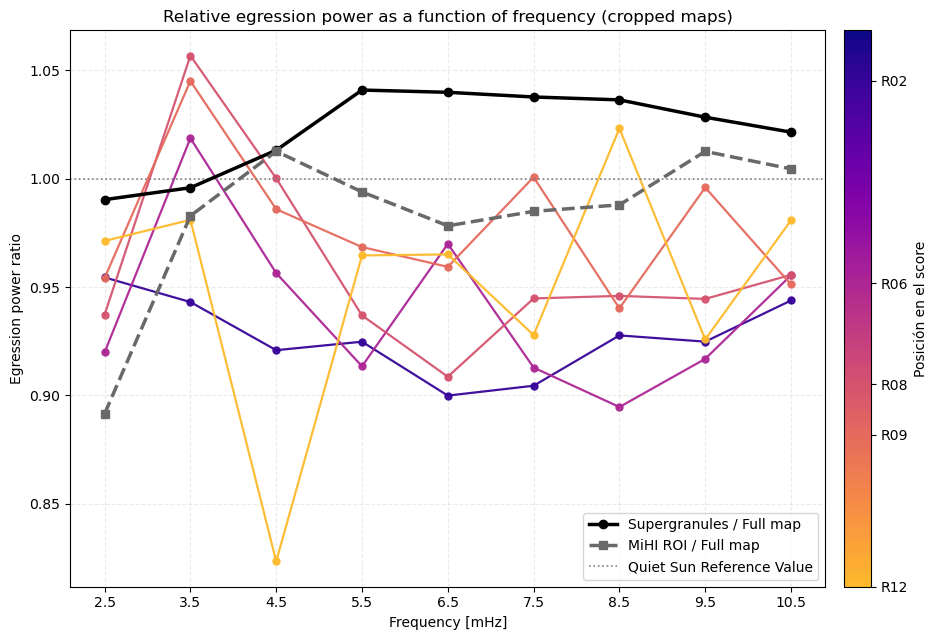

Region,Supergranules,MiHI ROI,R02,R06,R08,R09,R12
Frequency,,,,,,,
2.0-3.0 mHz,0.990,0.892,0.954,0.920,0.937,0.954,0.971
3.0-4.0 mHz,0.996,0.983,0.943,1.019,1.057,1.045,0.981
4.0-5.0 mHz,1.013,1.013,0.921,0.956,1.000,0.986,0.823
5.0-6.0 mHz,1.041,0.994,0.925,0.913,0.937,0.968,0.965
6.0-7.0 mHz,1.040,0.978,0.900,0.970,0.909,0.959,0.965
7.0-8.0 mHz,1.038,0.985,0.904,0.913,0.945,1.001,0.928
8.0-9.0 mHz,1.036,0.988,0.928,0.895,0.946,0.940,1.023
9.0-10.0 mHz,1.028,1.013,0.925,0.917,0.945,0.996,0.926
10.0-11.0 mHz,1.022,1.005,0.944,0.955,0.956,0.951,0.981


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# 1. REFERENCIA: MEDIA DEL MAPA RECORTADO (cropped) POR BANDA
# ============================================================
# Se alinea por nombre de banda (no por posición) para evitar
# errores si alguna tabla cambia de orden.

cropped_ref = (
    cropped_results_df
    .set_index("Frequency")["Cropped map mean"]
    .reindex(mean_table.index.astype(str))
)

if cropped_ref.isna().any():
    raise ValueError(f"Bandas sin referencia cropped: {list(cropped_ref[cropped_ref.isna()].index)}")

# Centro de cada banda a partir de su etiqueta ("2.0-3.0 mHz" -> 2.5)
freq_centers = np.array([
    np.mean([float(v) for v in f.replace(" mHz", "").split("-")])
    for f in mean_table.index.astype(str)
])


# ============================================================
# 2. RATIOS REGIÓN / MAPA COMPLETO (cropped)
# ============================================================

ratio_table = mean_table.div(cropped_ref.to_numpy(), axis=0)
ratio_table = ratio_table.drop(columns="Full map")
ratio_table.index = mean_table.index.astype(str)

pore_names = [str(n) for n in region_names]       # R01 ... R12 (orden de score)

# Poros que se van a graficar
selected_pores = ["R02", "R06", "R08", "R09", "R12"]
sel_idx = [pore_names.index(p) for p in selected_pores]

# Guardar en la tabla de mapas recortados (como en tu celda original)
cropped_results_df = cropped_results_df.set_index("Frequency")
for col in ratio_table.columns:
    cropped_results_df[f"{col} / Full map"] = ratio_table[col]
cropped_results_df = cropped_results_df.reset_index()

ratio_table.to_csv("../data/2018_08_25/pores/egression_ratio_cropped.csv")


# ============================================================
# 3. COLORES DE LOS POROS
# ============================================================
# color_by = "rank" -> color según posición en el score (R01 ... R12)
# color_by = "B"    -> color según <|B|> del día de cada poro

color_by = "rank"

# "plasma" recortada (sin el amarillo final, que casi no se ve sobre blanco)
base = mpl.colors.LinearSegmentedColormap.from_list(
    "plasma_cut", plt.get_cmap("plasma")(np.linspace(0.0, 0.85, 256))
)

# Oscuro = mejor score / mayor |B|
if color_by == "B":
    cmap = base.reversed()
    color_values = pores["B_day_abs"]
    norm = mpl.colors.Normalize(vmin=color_values.min(), vmax=color_values.max())
    cbar_label = r"$\langle|B|\rangle$ día [G]"
else:
    cmap = base
    color_values = np.arange(1, len(pore_names) + 1)
    norm = mpl.colors.Normalize(vmin=1, vmax=len(pore_names))
    cbar_label = "Posición en el score"

pore_colors = cmap(norm(color_values))


# ============================================================
# 4. GRAFICAR
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6.5))

# --- Poros seleccionados ---
for k in sel_idx:
    ax.plot(
        freq_centers, ratio_table[pore_names[k]],
        marker="o", markersize=5, linewidth=1.6, alpha=0.95,
        color=pore_colors[k], label=pore_names[k],
    )
# --- Supergránulos y MiHI (encima, en negro/gris) ---
ax.plot(freq_centers, ratio_table["Supergranules"],
        marker="o", linestyle="-", linewidth=2.5, color="black",
        label="Supergranules / Full map", zorder=5)

ax.plot(freq_centers, ratio_table["MiHI ROI"],
        marker="s", linestyle="--", linewidth=2.5, color="dimgray",
        label="MiHI ROI / Full map", zorder=5)

# --- Referencia Sol quieto ---
ax.axhline(1.0, linestyle=":", linewidth=1.2, color="gray",
           label="Quiet Sun Reference Value")

# --- Barra de color ---
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(cbar_label)
if color_by == "rank":
    cbar.set_ticks([k + 1 for k in sel_idx])
    cbar.set_ticklabels(selected_pores)
    cbar.ax.invert_yaxis()           # R01 arriba
else:
    # Marca el <|B|> de cada poro seleccionado en la barra
    cbar.set_ticks(color_values[sel_idx])
    cbar.set_ticklabels([f"{pore_names[k]} ({color_values[k]:.0f} G)" for k in sel_idx])
# --- Formato ---
ax.set_xlabel("Frequency [mHz]")
ax.set_ylabel("Egression power ratio")
ax.set_xticks(freq_centers)
ax.set_title("Relative egression power as a function of frequency (cropped maps)")
ax.grid(alpha=0.25, linestyle="--")

# Leyenda solo con SG, MiHI y referencia (los poros los explica la barra de color)
handles, labels = ax.get_legend_handles_labels()
keep = [i for i, l in enumerate(labels) if l not in pore_names]
ax.legend([handles[i] for i in keep], [labels[i] for i in keep], loc="best")

plt.tight_layout()
plt.show()

display(ratio_table[["Supergranules", "MiHI ROI"] + selected_pores]
        .style.format("{:.3f}")
        .background_gradient(cmap="RdBu_r", axis=None, vmin=0.5, vmax=1.5))

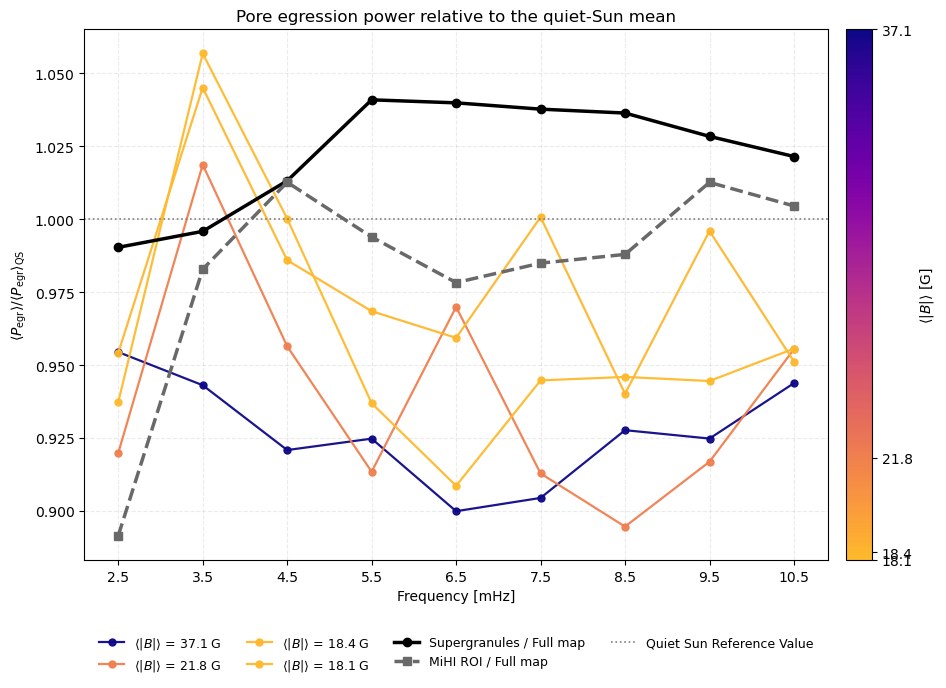

,Supergranules,MiHI ROI,<|B|> = 37.1 G,<|B|> = 21.8 G,<|B|> = 18.4 G,<|B|> = 18.1 G
Frequency,,,,,,
2.0-3.0 mHz,0.990,0.892,0.954,0.920,0.954,0.937
3.0-4.0 mHz,0.996,0.983,0.943,1.019,1.045,1.057
4.0-5.0 mHz,1.013,1.013,0.921,0.956,0.986,1.000
5.0-6.0 mHz,1.041,0.994,0.925,0.913,0.968,0.937
6.0-7.0 mHz,1.040,0.978,0.900,0.970,0.959,0.909
7.0-8.0 mHz,1.038,0.985,0.904,0.913,1.001,0.945
8.0-9.0 mHz,1.036,0.988,0.928,0.895,0.940,0.946
9.0-10.0 mHz,1.028,1.013,0.925,0.917,0.996,0.945
10.0-11.0 mHz,1.022,1.005,0.944,0.955,0.951,0.956


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# 1. REFERENCIA: MEDIA DEL MAPA RECORTADO (cropped) POR BANDA
# ============================================================
# Se alinea por nombre de banda (no por posición) para evitar
# errores si alguna tabla cambia de orden.

cropped_ref = (
    cropped_results_df
    .set_index("Frequency")["Cropped map mean"]
    .reindex(mean_table.index.astype(str))
)

if cropped_ref.isna().any():
    raise ValueError(f"Bandas sin referencia cropped: {list(cropped_ref[cropped_ref.isna()].index)}")

# Centro de cada banda a partir de su etiqueta ("2.0-3.0 mHz" -> 2.5)
freq_centers = np.array([
    np.mean([float(v) for v in f.replace(" mHz", "").split("-")])
    for f in mean_table.index.astype(str)
])


# ============================================================
# 2. RATIOS REGIÓN / MAPA COMPLETO (cropped)
# ============================================================

ratio_table = mean_table.div(cropped_ref.to_numpy(), axis=0)
ratio_table = ratio_table.drop(columns="Full map")
ratio_table.index = mean_table.index.astype(str)

pore_names = [str(n) for n in region_names]       # R01 ... R12 (orden de score)

# Guardar en la tabla de mapas recortados (se guardan los 12 poros)
cropped_results_df = cropped_results_df.set_index("Frequency")
for col in ratio_table.columns:
    cropped_results_df[f"{col} / Full map"] = ratio_table[col]
cropped_results_df = cropped_results_df.reset_index()

ratio_table.to_csv("../data/2018_08_25/pores/egression_ratio_cropped.csv")


# ============================================================
# 3. POROS SELECCIONADOS Y SU CAMPO MAGNÉTICO MEDIO
# ============================================================

selected_pores = ["R02", "R06", "R08", "R09"]
sel_idx = [pore_names.index(p) for p in selected_pores]

B_mean = np.asarray(pores["B_day_abs"])          # <|B|> del día, en el mismo orden R01...R12
B_sel  = B_mean[sel_idx]

# Ordenar de mayor a menor |B| (así también queda ordenada la leyenda)
order_sel = np.argsort(-B_sel)
sel_idx   = [sel_idx[i] for i in order_sel]
B_sel     = B_sel[order_sel]


# ============================================================
# 4. COLORES SEGÚN <|B|>
# ============================================================
# "plasma" recortada (sin el amarillo final, que casi no se ve sobre blanco)
# Oscuro = mayor |B|

base = mpl.colors.LinearSegmentedColormap.from_list(
    "plasma_cut", plt.get_cmap("plasma")(np.linspace(0.0, 0.85, 256))
)
cmap = base.reversed()

# Escala normalizada solo con los poros graficados (máximo contraste)
norm = mpl.colors.Normalize(vmin=B_sel.min(), vmax=B_sel.max())


# ============================================================
# 5. GRAFICAR
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# --- Poros seleccionados (etiqueta = campo magnético medio) ---
for k, B in zip(sel_idx, B_sel):
    ax.plot(
        freq_centers, ratio_table[pore_names[k]],
        marker="o", markersize=5, linewidth=1.6, alpha=0.95,
        color=cmap(norm(B)),
        label=rf"$\langle|B|\rangle$ = {B:.1f} G",
    )

# --- Supergránulos y MiHI (encima, en negro/gris) ---
ax.plot(freq_centers, ratio_table["Supergranules"],
        marker="o", linestyle="-", linewidth=2.5, color="black",
        label="Supergranules / Full map", zorder=5)

ax.plot(freq_centers, ratio_table["MiHI ROI"],
        marker="s", linestyle="--", linewidth=2.5, color="dimgray",
        label="MiHI ROI / Full map", zorder=5)

# --- Referencia Sol quieto ---
ax.axhline(1.0, linestyle=":", linewidth=1.2, color="gray",
           label="Quiet Sun Reference Value")

# --- Barra de color en Gauss, con marcas en cada poro ---
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$\langle|B|\rangle$ [G]")
cbar.set_ticks(B_sel)
cbar.set_ticklabels([f"{B:.1f}" for B in B_sel])

# --- Formato ---
ax.set_xlabel("Frequency [mHz]")
ax.set_ylabel(r"$\langle P_{\rm egr}\rangle / \langle P_{\rm egr}\rangle_{\rm QS}$")
ax.set_xticks(freq_centers)
ax.set_title("Pore egression power relative to the quiet-Sun mean")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=9, frameon=False)

plt.tight_layout()
plt.show()


# ============================================================
# 6. TABLA DE RATIOS (columnas = campo magnético medio)
# ============================================================

table_sel = ratio_table[["Supergranules", "MiHI ROI"] + [pore_names[k] for k in sel_idx]].copy()
table_sel.columns = ["Supergranules", "MiHI ROI"] + [f"<|B|> = {B:.1f} G" for B in B_sel]

display(table_sel.style.format("{:.3f}")
        .background_gradient(cmap="RdBu_r", axis=None, vmin=0.5, vmax=1.5))

In [18]:
from astropy.io import fits
import numpy as np

# ============================================================
# CAMPO MAGNÉTICO MEDIO EN LA REGIÓN MiHI (todo el día)
# ============================================================
# Mismo criterio que para los poros:
#   <|B|>(t) = media de |B| sobre los píxeles de la ROI en cada frame
#   <|B|> día = promedio temporal de <|B|>(t)

MAG_cube = "../data/2018_08_25/cubes/MAG_24.fits"
mihi_B_file = "../data/2018_08_25/pores/mihi_B_MAG_24.npz"

min_finite_fraction = 0.90   # frame válido si >= 90 % de la ROI es finita

with fits.open(MAG_cube, memmap=True, do_not_scale_image_data=True) as hdul:

    cube_raw = hdul[0].data
    hdr      = hdul[0].header

    # Los datos crudos hay que escalarlos: B = raw * BSCALE + BZERO
    bscale = hdr.get("BSCALE", 1.0)
    bzero  = hdr.get("BZERO", 0.0)
    blank  = hdr.get("BLANK", None) if np.issubdtype(cube_raw.dtype, np.integer) else None

    n_frames, ny_B, nx_B = cube_raw.shape

    # --------------------------------------------------------
    # Máscara MiHI (misma geometría que el magnetograma)
    # --------------------------------------------------------
    if (ny_B, nx_B) != tuple(shape_roi):
        raise ValueError(f"Magnetograma {(ny_B, nx_B)} ≠ geometría de la ROI {tuple(shape_roi)}")

    mihi_mask_B = roi_mask(px_roi, py_roi, (ny_B, nx_B))
    y_idx, x_idx = np.nonzero(mihi_mask_B)
    n_pix = y_idx.size

    print(f"Cubo: {cube_raw.shape} | píxeles en MiHI: {n_pix}")

    # --------------------------------------------------------
    # Series temporales
    # --------------------------------------------------------
    mihi_absB_t   = np.full(n_frames, np.nan)   # <|B|>(t)
    mihi_signB_t  = np.full(n_frames, np.nan)   # <B>(t) con signo
    mihi_stdB_t   = np.full(n_frames, np.nan)   # dispersión espacial de |B| en cada frame

    for t in range(n_frames):

        raw  = cube_raw[t, y_idx, x_idx]
        vals = raw.astype(np.float64)
        if blank is not None:
            vals[raw == blank] = np.nan
        vals = vals * bscale + bzero

        finite = np.isfinite(vals)
        if finite.sum() < min_finite_fraction * n_pix:
            continue

        v = vals[finite]
        mihi_absB_t[t]  = np.mean(np.abs(v))
        mihi_signB_t[t] = np.mean(v)
        mihi_stdB_t[t]  = np.std(np.abs(v))

        if (t + 1) % 200 == 0 or t == n_frames - 1:
            print(f"Processed {t + 1}/{n_frames} frames ({100*(t+1)/n_frames:.1f}%)")

# ============================================================
# RESULTADOS
# ============================================================

B_mihi        = np.nanmean(mihi_absB_t)     # <|B|> día  (comparable con B_day_abs de los poros)
B_mihi_std    = np.nanstd(mihi_absB_t)      # variabilidad temporal
B_mihi_signed = np.nanmean(mihi_signB_t)
B_mihi_t0     = mihi_absB_t[0]
n_valid       = np.isfinite(mihi_absB_t).sum()

print(f"\nFrames válidos: {n_valid}/{n_frames}")
print(f"<|B|> MiHI (día)      = {B_mihi:.2f} ± {B_mihi_std:.2f} G")
print(f"<|B|> MiHI (frame 0)  = {B_mihi_t0:.2f} G")
print(f"<B>   MiHI con signo  = {B_mihi_signed:.2f} G")

np.savez(
    mihi_B_file,
    B_day_abs     = B_mihi,
    B_day_std     = B_mihi_std,
    B_day_signed  = B_mihi_signed,
    B_t0_abs      = B_mihi_t0,
    absB_series   = mihi_absB_t.astype(np.float32),
    n_pixels      = n_pix,
    source_cube   = np.array(MAG_cube),
)
print("Guardado:", mihi_B_file)


Cubo: (1920, 1024, 1024) | píxeles en MiHI: 278
Processed 200/1920 frames (10.4%)
Processed 400/1920 frames (20.8%)
Processed 600/1920 frames (31.2%)
Processed 800/1920 frames (41.7%)
Processed 1000/1920 frames (52.1%)
Processed 1200/1920 frames (62.5%)
Processed 1400/1920 frames (72.9%)
Processed 1600/1920 frames (83.3%)
Processed 1800/1920 frames (93.8%)
Processed 1920/1920 frames (100.0%)

Frames válidos: 1920/1920
<|B|> MiHI (día)      = 7.11 ± 2.21 G
<|B|> MiHI (frame 0)  = 10.62 G
<B>   MiHI con signo  = 0.89 G
Guardado: ../data/2018_08_25/pores/mihi_B_MAG_24.npz


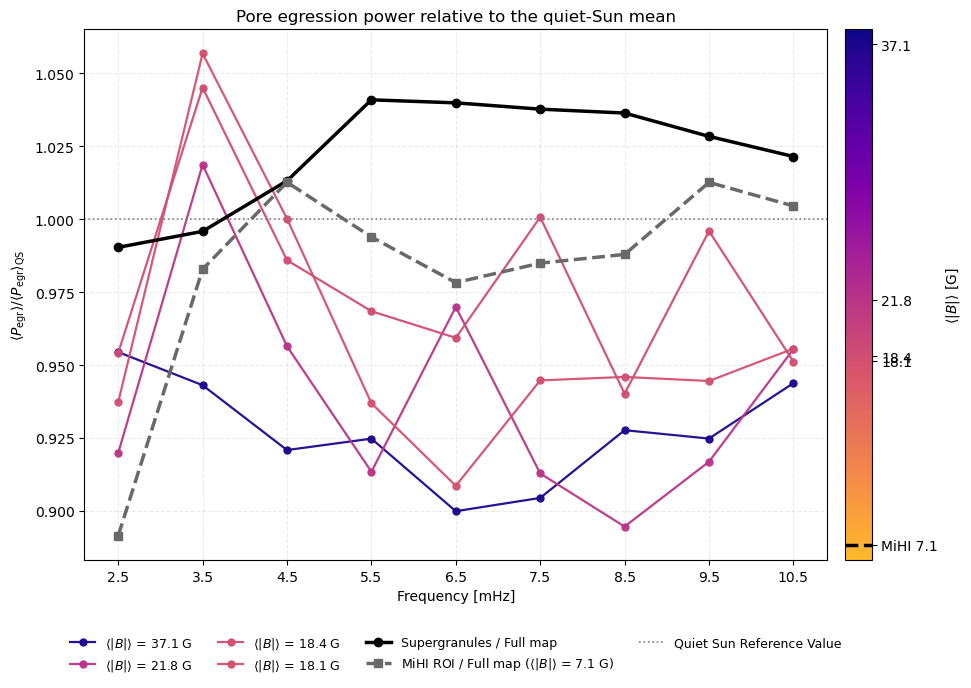

,Supergranules,MiHI ROI,<|B|> = 37.1 G,<|B|> = 21.8 G,<|B|> = 18.4 G,<|B|> = 18.1 G
Frequency,,,,,,
2.0-3.0 mHz,0.990,0.892,0.954,0.920,0.954,0.937
3.0-4.0 mHz,0.996,0.983,0.943,1.019,1.045,1.057
4.0-5.0 mHz,1.013,1.013,0.921,0.956,0.986,1.000
5.0-6.0 mHz,1.041,0.994,0.925,0.913,0.968,0.937
6.0-7.0 mHz,1.040,0.978,0.900,0.970,0.959,0.909
7.0-8.0 mHz,1.038,0.985,0.904,0.913,1.001,0.945
8.0-9.0 mHz,1.036,0.988,0.928,0.895,0.940,0.946
9.0-10.0 mHz,1.028,1.013,0.925,0.917,0.996,0.945
10.0-11.0 mHz,1.022,1.005,0.944,0.955,0.951,0.956


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ============================================================
# 1. REFERENCIA: MEDIA DEL MAPA RECORTADO (cropped) POR BANDA
# ============================================================
# Se alinea por nombre de banda (no por posición) para evitar
# errores si alguna tabla cambia de orden.

cropped_ref = (
    cropped_results_df
    .set_index("Frequency")["Cropped map mean"]
    .reindex(mean_table.index.astype(str))
)

if cropped_ref.isna().any():
    raise ValueError(f"Bandas sin referencia cropped: {list(cropped_ref[cropped_ref.isna()].index)}")

# Centro de cada banda a partir de su etiqueta ("2.0-3.0 mHz" -> 2.5)
freq_centers = np.array([
    np.mean([float(v) for v in f.replace(" mHz", "").split("-")])
    for f in mean_table.index.astype(str)
])


# ============================================================
# 2. RATIOS REGIÓN / MAPA COMPLETO (cropped)
# ============================================================

ratio_table = mean_table.div(cropped_ref.to_numpy(), axis=0)
ratio_table = ratio_table.drop(columns="Full map")
ratio_table.index = mean_table.index.astype(str)

pore_names = [str(n) for n in region_names]       # R01 ... R12 (orden de score)

# Guardar en la tabla de mapas recortados (se guardan los 12 poros)
cropped_results_df = cropped_results_df.set_index("Frequency")
for col in ratio_table.columns:
    cropped_results_df[f"{col} / Full map"] = ratio_table[col]
cropped_results_df = cropped_results_df.reset_index()

ratio_table.to_csv("../data/2018_08_25/pores/egression_ratio_cropped.csv")


# ============================================================
# 3. POROS SELECCIONADOS Y SU CAMPO MAGNÉTICO MEDIO
# ============================================================

selected_pores = ["R02", "R06", "R08", "R09"]
sel_idx = [pore_names.index(p) for p in selected_pores]

B_mean = np.asarray(pores["B_day_abs"])          # <|B|> del día, en el mismo orden R01...R12
B_sel  = B_mean[sel_idx]

# Ordenar de mayor a menor |B| (así también queda ordenada la leyenda)
order_sel = np.argsort(-B_sel)
sel_idx   = [sel_idx[i] for i in order_sel]
B_sel     = B_sel[order_sel]


# ============================================================
# 4. COLORES SEGÚN <|B|>
# ============================================================
# "plasma" recortada (sin el amarillo final, que casi no se ve sobre blanco)
# Oscuro = mayor |B|

base = mpl.colors.LinearSegmentedColormap.from_list(
    "plasma_cut", plt.get_cmap("plasma")(np.linspace(0.0, 0.85, 256))
)
cmap = base.reversed()

# Escala normalizada solo con los poros graficados (máximo contraste)
B_lo, B_hi = min(B_sel.min(), B_mihi), max(B_sel.max(), B_mihi)
pad = 0.03 * (B_hi - B_lo)          # margen para que la marca de MiHI no quede en el borde
norm = mpl.colors.Normalize(vmin=B_lo - pad, vmax=B_hi + pad)


# ============================================================
# 5. GRAFICAR
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# --- Poros seleccionados (etiqueta = campo magnético medio) ---
for k, B in zip(sel_idx, B_sel):
    ax.plot(
        freq_centers, ratio_table[pore_names[k]],
        marker="o", markersize=5, linewidth=1.6, alpha=0.95,
        color=cmap(norm(B)),
        label=rf"$\langle|B|\rangle$ = {B:.1f} G",
    )

# --- Supergránulos y MiHI (encima, en negro/gris) ---
ax.plot(freq_centers, ratio_table["Supergranules"],
        marker="o", linestyle="-", linewidth=2.5, color="black",
        label="Supergranules / Full map", zorder=5)

ax.plot(freq_centers, ratio_table["MiHI ROI"],
        marker="s", linestyle="--", linewidth=2.5, color="dimgray",
        label=rf"MiHI ROI / Full map ($\langle|B|\rangle$ = {B_mihi:.1f} G)", zorder=5)

# --- Referencia Sol quieto ---
ax.axhline(1.0, linestyle=":", linewidth=1.2, color="gray",
           label="Quiet Sun Reference Value")

# --- Barra de color en Gauss, con marcas en cada poro ---
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$\langle|B|\rangle$ [G]")
cbar.ax.axhline(B_mihi, color="black", linewidth=2.5, linestyle="--")
cbar.set_ticks(list(B_sel) + [B_mihi])
cbar.set_ticklabels([f"{B:.1f}" for B in B_sel] + [f"MiHI {B_mihi:.1f}"])

# --- Formato ---
ax.set_xlabel("Frequency [mHz]")
ax.set_ylabel(r"$\langle P_{\rm egr}\rangle / \langle P_{\rm egr}\rangle_{\rm QS}$")
ax.set_xticks(freq_centers)
ax.set_title("Pore egression power relative to the quiet-Sun mean")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=9, frameon=False)

plt.tight_layout()
plt.show()


# ============================================================
# 6. TABLA DE RATIOS (columnas = campo magnético medio)
# ============================================================

table_sel = ratio_table[["Supergranules", "MiHI ROI"] + [pore_names[k] for k in sel_idx]].copy()
table_sel.columns = ["Supergranules", "MiHI ROI"] + [f"<|B|> = {B:.1f} G" for B in B_sel]

display(table_sel.style.format("{:.3f}")
        .background_gradient(cmap="RdBu_r", axis=None, vmin=0.5, vmax=1.5))